<a href="https://colab.research.google.com/github/Architag1503/Colab/blob/main/KMeansClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs #helps to generate the cluster not make the cluster
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [8]:
X , y_true = make_blobs(n_samples=500,centers=3,cluster_std=0.60,random_state=42)
X

array([[-6.1900632 , -7.30201545],
       [ 3.02174685,  1.94059276],
       [ 5.9537606 ,  1.48819071],
       [-2.74446251,  8.13617716],
       [ 5.36060719,  1.72832446],
       [ 5.13808033,  1.45951939],
       [-5.34357647, -6.93774553],
       [ 4.80215293,  1.94302682],
       [ 3.99930658,  1.88774199],
       [-7.25451834, -6.86445496],
       [ 4.25193511,  1.32424088],
       [-1.81404028,  8.52187674],
       [-1.2293776 ,  7.84303345],
       [-2.16666332,  9.69562551],
       [ 4.81374375,  3.21841016],
       [ 5.27493353,  0.91792599],
       [-2.5524037 ,  9.61640587],
       [-7.5532604 , -6.65066375],
       [-6.8302568 , -6.24082137],
       [-3.17299861,  8.29656215],
       [ 3.80073829,  2.31095123],
       [-2.38387947,  7.83848405],
       [ 4.98581301,  2.15991978],
       [-5.94031277, -6.91955975],
       [-7.14748736, -6.7636556 ],
       [ 4.87655012,  1.720579  ],
       [ 4.48689251,  2.87556548],
       [-6.4081471 , -6.62483506],
       [-6.71939703,

In [9]:
df = pd.DataFrame(X,columns=['feature1','feature2'])
df

,feature1,feature2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-9.69818350e-01, -1.33993820e+00],
       [ 9.63343617e-01,  8.22475346e-02],
       [ 1.57864695e+00,  1.26351772e-02],
       [-2.46735247e-01,  1.03557927e+00],
       [ 1.45416962e+00,  4.95852224e-02],
       [ 1.40747082e+00,  8.22344111e-03],
       [-7.92177264e-01, -1.28388698e+00],
       [ 1.33697413e+00,  8.26220693e-02],
       [ 1.16849128e+00,  7.41152400e-02],
       [-1.19320161e+00, -1.27260956e+00],
       [ 1.22150712e+00, -1.25922376e-02],
       [-5.14797137e-02,  1.09492794e+00],
       [ 7.12157877e-02,  9.90472440e-01],
       [-1.25480095e-01,  1.27553591e+00],
       [ 1.33940654e+00,  2.78868839e-01],
       [ 1.43619041e+00, -7.51130357e-02],
       [-2.06430378e-01,  1.26334617e+00],
       [-1.25589470e+00, -1.23971291e+00],
       [-1.10416740e+00, -1.17664933e+00],
       [-3.36666506e-01,  1.06025816e+00],
       [ 1.12682035e+00,  1.39235617e-01],
       [-1.71064404e-01,  9.89772412e-01],
       [ 1.37551647e+00,  1.15995990e-01],
       [-9.

In [13]:
#Implementation of Elbow method to judge the best value of K
inertia = []
K_range = range(1,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

inertia

[1000.0000000000006,
 297.8954141051723,
 11.575484723104985,
 9.752067977356848,
 8.257175272446279,
 6.917577320416797,
 6.334755391595288,
 5.704177177901426,
 5.060234133532074,
 4.7623618981303935]

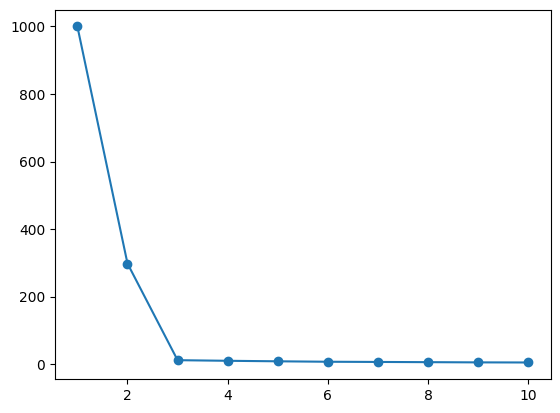

In [15]:
plt.plot(K_range , inertia , marker='o')

In [16]:
kmeans_final = KMeans(n_clusters=3,random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)
cluster_labels

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0,

In [17]:
df['cluster' ] = cluster_labels

<Axes: xlabel='feature1', ylabel='feature2'>

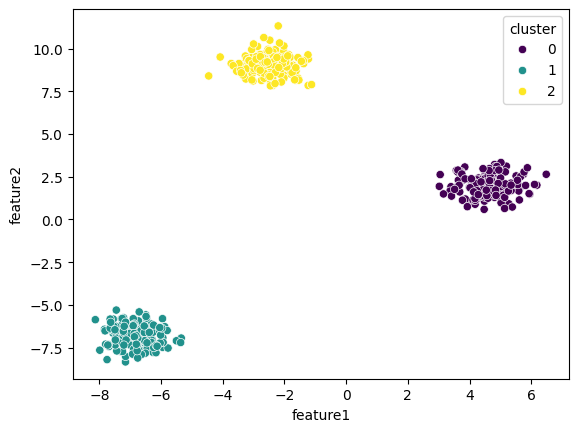

In [18]:
sns.scatterplot(x=df['feature1'] , y=df['feature2'] , hue=df['cluster'] , palette='viridis')